### Gravitational wave inference

This tutorial demonstrates how to run parameter estimation on a reduced parameter space for an injected gravitational wave signal with `bilby`.

This example estimates the masses using a uniform prior in both component masses and distance using a uniform in comoving volume prior on luminosity distance between luminosity distances of 100 Mpc and 5 Gpc, the cosmology is [Planck15](https://docs.astropy.org/en/stable/api/astropy.cosmology.realizations.Planck15.html).


This notebook is based on [this Python script](https://github.com/bilby-dev/bilby/blob/main/examples/gw_examples/injection_examples/fast_tutorial.py). 

In [1]:
# this ensures correct using of cores 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [2]:
import bilby
from gwpy.timeseries import TimeSeries
import numpy as np
from gwpy.signal.filter_design import bandpass, concatenate_zpks
from tqdm import tqdm

/Users/filippo/miniconda3/envs/bayes_env/lib/python3.11/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [3]:
# we need to switch off some bilby warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="bilby")
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [4]:
# These lines make plots look nicer
import matplotlib.pyplot as plt
font_value = 20

# Set global Matplotlib settings for a clean look without grids
plt.rcParams['axes.grid'] = False      # Disable grid lines for all axes
plt.rcParams['grid.color'] = 'none'    # Just in case, ensure grid color is invisible
# Set matplotlib to render LaTeX fonts
plt.rcParams.update({
    "mathtext.fontset" : "stix",
    "font.family" : "STIXGeneral",
    "axes.labelsize": font_value ,           # Font size for axis labels
    "axes.titlesize": font_value ,           # Font size for titles
    "font.size": font_value ,                # General font size
    "legend.fontsize": font_value ,          # Font size for legend
    "xtick.labelsize": font_value ,          # Font size for x-axis ticks
    "ytick.labelsize": font_value ,          # Font size for y-axis ticks
})

# the following lines are necessary on Macs to make plot look even nicer
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina") # Enable retina display output in Jupyter

In [5]:
# Set the duration and sampling frequency of the data segment that we're
# going to inject the signal into
duration = 4.0
sampling_frequency = 2048.0
minimum_frequency = 20

In [6]:
# Specify the output directory and the name of the simulation.
outdir = "outdir_gw"
label = "fast_tutorial"
bilby.core.utils.setup_logger(outdir=outdir, label=label)

In [7]:
# Set up a random seed for result reproducibility.
bilby.core.utils.random.seed(42)

### Injected signal

We are going to inject a binary black hole waveform.  We first establish a dictionary of parameters that includes all of the different waveform parameters, including masses of the two black holes (`mass_1`, `mass_2`), spins of both black holes (`a`, `tilt`, `phi`), etc.

![Figure_6.png](Figure_6.png)

In [8]:
injection_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    a_1=0.,
    a_2=0.,
    tilt_1=0.,
    tilt_2=0.,
    phi_12=0.,
    phi_jl=0.,
    luminosity_distance=1500.0,
    theta_jn=0.4,
    psi=2.659,
    phase=1.3,
    geocent_time=1126259642.413,
    ra=1.375,
    dec=-1.2108,
)

In [9]:
# Fixed arguments passed into the source model
waveform_arguments = dict(
    waveform_approximant="TaylorF2",
    reference_frequency=50.0,
    minimum_frequency=minimum_frequency,
)

# Create the waveform_generator using a LAL BinaryBlackHole source function
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
)

14:23 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=4.0, sampling_frequency=2048.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'TaylorF2', 'reference_frequency': 50.0, 'minimum_frequency': 20})


### The interferometers.  

In this case we'll use two interferometers (LIGO-Hanford (H1), LIGO-Livingston (L1). These default to their design sensitivity

In [10]:

ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])

ifos.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=injection_parameters["geocent_time"] - 2,
)

hs = ifos.inject_signal(
    waveform_generator=waveform_generator, parameters=injection_parameters
)

14:23 bilby INFO    : Injected signal in H1:
14:23 bilby INFO    :   optimal SNR = 17.97
14:23 bilby INFO    :   matched filter SNR = 18.23-0.33j
14:23 bilby INFO    :   mass_1 = 36.0
14:23 bilby INFO    :   mass_2 = 29.0
14:23 bilby INFO    :   a_1 = 0.0
14:23 bilby INFO    :   a_2 = 0.0
14:23 bilby INFO    :   tilt_1 = 0.0
14:23 bilby INFO    :   tilt_2 = 0.0
14:23 bilby INFO    :   phi_12 = 0.0
14:23 bilby INFO    :   phi_jl = 0.0
14:23 bilby INFO    :   luminosity_distance = 1500.0
14:23 bilby INFO    :   theta_jn = 0.4
14:23 bilby INFO    :   psi = 2.659
14:23 bilby INFO    :   phase = 1.3
14:23 bilby INFO    :   geocent_time = 1126259642.413
14:23 bilby INFO    :   ra = 1.375
14:23 bilby INFO    :   dec = -1.2108
14:23 bilby INFO    : Injected signal in L1:
14:23 bilby INFO    :   optimal SNR = 14.55
14:23 bilby INFO    :   matched filter SNR = 14.27+0.43j
14:23 bilby INFO    :   mass_1 = 36.0
14:23 bilby INFO    :   mass_2 = 29.0
14:23 bilby INFO    :   a_1 = 0.0
14:23 bilby INF

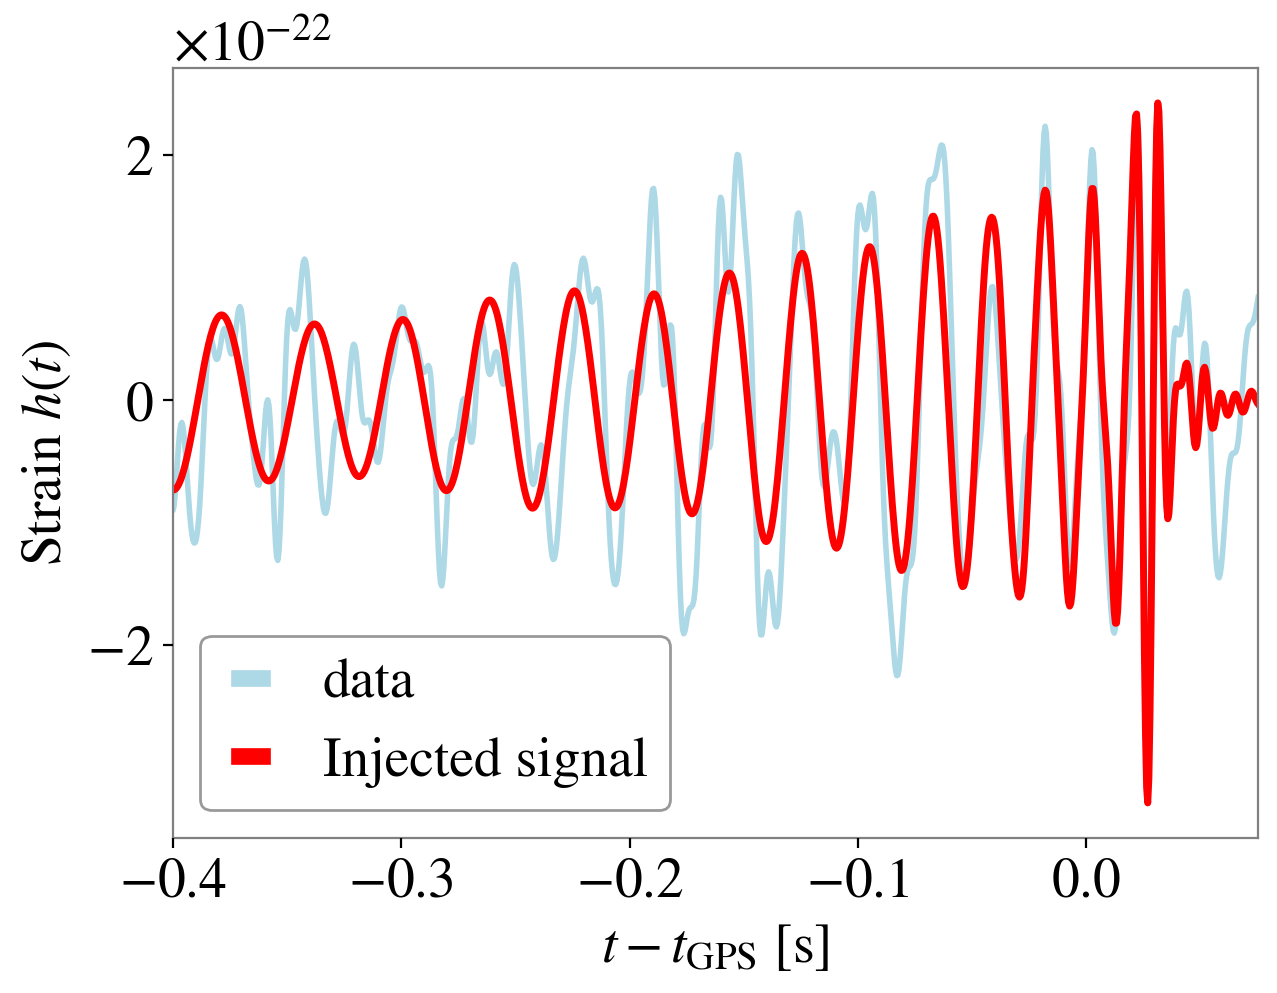

In [11]:
# We quickly plot the data 
fig, ax = plt.subplots(figsize=(7,5))

timeseries = TimeSeries(
            data=ifos[0].strain_data.time_domain_strain, 
            times=ifos[0].strain_data.time_array)

bandpass_frequencies = [10,150]

zpks = [bandpass(bandpass_frequencies[0], bandpass_frequencies[1],ifos[0].strain_data.sampling_frequency)]
zpk = concatenate_zpks(*zpks)

t0 = injection_parameters['geocent_time']

x = ifos[0].strain_data.time_array - t0

ax.plot(x, timeseries.filter(zpk, filtfilt=True), label="data", lw = 2,
       color='lightblue')


# Pure signal strain (no noise)
signal_fd = ifos[0].get_detector_response(
    waveform_generator.frequency_domain_strain(), injection_parameters
)
signal_td = np.fft.irfft(signal_fd) * sampling_frequency
signal_clean = TimeSeries(
                data=signal_td, times=ifos[0].strain_data.time_array)


ax.plot(x, signal_clean.filter(zpk, filtfilt=True), label="Injected signal", lw = 2.5, color = 'r')


ax.set_xlim([-0.4,0.075])

ax.set_xlabel("$t - t_{\mathrm{GPS}}$ [s]")
ax.set_ylabel("Strain $h(t)$")
ax.legend(fancybox=True)
fig.savefig("{}/{}_time_domain_data.png".format(outdir, label), dpi = 300) 

### Priors

Set up a prior dictionary. By default we will sample all terms in the signal models.  However, this will take a long time for the calculation, so for this example we will set almost all of the priors to be equall to their injected values.  This implies the prior is a delta function at the true, injected value.  In reality, the sampler implementation is smart enough to not sample any parameter that has a delta-function prior. The above list does *not* include `mass_1`, `mass_2`, `theta_jn` and `luminosity_distance`, which means those are the parameters that will be included in the sampler. 

In [12]:
priors = bilby.gw.prior.BBHPriorDict()
for key in [
    "a_1",
    "a_2",
    "tilt_1",
    "tilt_2",
    "phi_12",
    "phi_jl",
    "psi",
    "ra",
    "dec",
    "geocent_time",
    "phase",
]:
    priors[key] = bilby.core.prior.DeltaFunction(injection_parameters[key])
    
priors['chirp_mass'] = bilby.gw.prior.UniformInComponentsChirpMass(minimum=15, maximum=50, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary='reflective')
priors['mass_ratio'] = bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.5, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary='reflective', equal_mass=False)
priors['luminosity_distance'] = bilby.gw.prior.UniformSourceFrame(minimum=100.0, maximum=5000.0, cosmology='Planck15', name='luminosity_distance', latex_label='$D_\mathrm{L}$', unit='Mpc', boundary='reflective')

del priors['mass_1']
del priors['mass_2']

# Perform a check that the prior does not extend to a parameter space longer than the data
priors.validate_prior(duration, minimum_frequency)

14:23 bilby INFO    : No prior given, using default BBH priors in /Users/filippo/miniconda3/envs/bayes_env/lib/python3.11/site-packages/bilby/gw/prior_files/precessing_spins_bbh.prior.


True

We initialise the likelihood by passing in the interferometer data (ifos) and the waveform generator

In [13]:

likelihood = bilby.gw.GravitationalWaveTransient(
    interferometers=ifos, waveform_generator=waveform_generator
)


### Sampling

In gravitational-wave data analysis, [standard Markov Chain Monte Carlo (MCMC) methods](https://chi-feng.github.io/mcmc-demo/app.html?algorithm=RandomWalkMH&target=multimodal) are rarely used because they tend to be inefficient in the high-dimensional and complex parameter spaces typical of these problems.

A sampling algorithm that has proven to be much more effective is **Nested Sampling**.

You can find a visual and intuitive explanation of how Nested Sampling works [here](https://chi-feng.github.io/mcmc-demo/app.html?algorithm=RadFriends-NS&target=multimodal).

As shown in the animation above, Nested Sampling explores the posterior distribution by progressively shrinking the prior volume using a large number of so-called **live points**. This strategy makes it significantly more efficient at exploring the complicated posterior distributions that arise when estimating gravitational-wave source parameters.

The primary goal of Nested Sampling is to compute the **Bayesian evidence**. Posterior samples are produced as a by-product of this calculation. As you will see in the next cell, `bilby` will also output the evidence of the model.

In the gravitational-wave community, the most widely used implementation of Nested Sampling is **`dynesty`**.

Once the sampling is complete, the output directory will contain several diagnostic plots. In particular, you may want to open the `_trace.png` file, which illustrates how the parameter space was explored during the sampling process.

In [14]:
# Run sampler.  In this case we're going to use the `dynesty` sampler
# it may take a while
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    
    sampler="dynesty", # best sampler for GW inference, implementing nested sampling
    nlive=1000,
    
    npool=8, # base this parameter on the number of cores you have on you laptop, check with htop
    injection_parameters=injection_parameters,
    outdir=outdir,
    label=label,
    result_class=bilby.gw.result.CBCResult,
    #clean=True, # (un)comment this if you want to overwrite
)

14:23 bilby INFO    : Running for label 'fast_tutorial', output will be saved to 'outdir_gw'
14:23 bilby INFO    : Using lal version 7.7.0
14:23 bilby INFO    : Using lal git version Branch: None;Tag: lal-v7.7.0;Id: ef36dfdf49181b9b376a867b55a14463783de545;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed
14:23 bilby INFO    : Using lalsimulation version 6.2.0
14:23 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsimulation-v6.2.0;Id: 1338470a6165fb4b4c98bccdd0efe961f05bc8e0;;Builder: Adam Mercer <adam.mercer@ligo.org>;Repository status: CLEAN: All modifications committed
14:23 bilby INFO    : Analysis priors:
14:23 bilby INFO    : mass_ratio=bilby.gw.prior.UniformInComponentsMassRatio(minimum=0.5, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary='reflective', equal_mass=False)
14:23 bilby INFO    : chirp_mass=bilby.gw.prior.UniformInComponentsChirpMass(minimum=15, maximum=50, name='chirp_mass', l

16073it [02:51, 49.81it/s, bound:974 nc:  1 ncall:8.7e+05 eff:2.0% logz-ratio=255.03+/-0.11 dlogz:0.000678>0.1]

14:27 bilby INFO    : Written checkpoint file outdir_gw/fast_tutorial_resume.pickle
14:27 bilby INFO    : Starting to close worker pool.
14:27 bilby INFO    : Finished closing worker pool.


16073it [02:56, 91.00it/s, bound:974 nc:  1 ncall:8.7e+05 eff:2.0% logz-ratio=255.03+/-0.11 dlogz:9.68e-05>0.1]

14:27 bilby INFO    : Rejection sampling nested samples to obtain 3358 posterior samples
14:27 bilby INFO    : Sampling time: 0:02:56.374506
14:27 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 


14:27 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
14:27 bilby INFO    : Summary of results:
nsamples: 3358
ln_noise_evidence: -8389.759
ln_evidence: -8134.730 +/-  0.139
ln_bayes_factor: 255.028 +/-  0.139



In [15]:
result.priors['mass_ratio'].latex_label

'$q$'

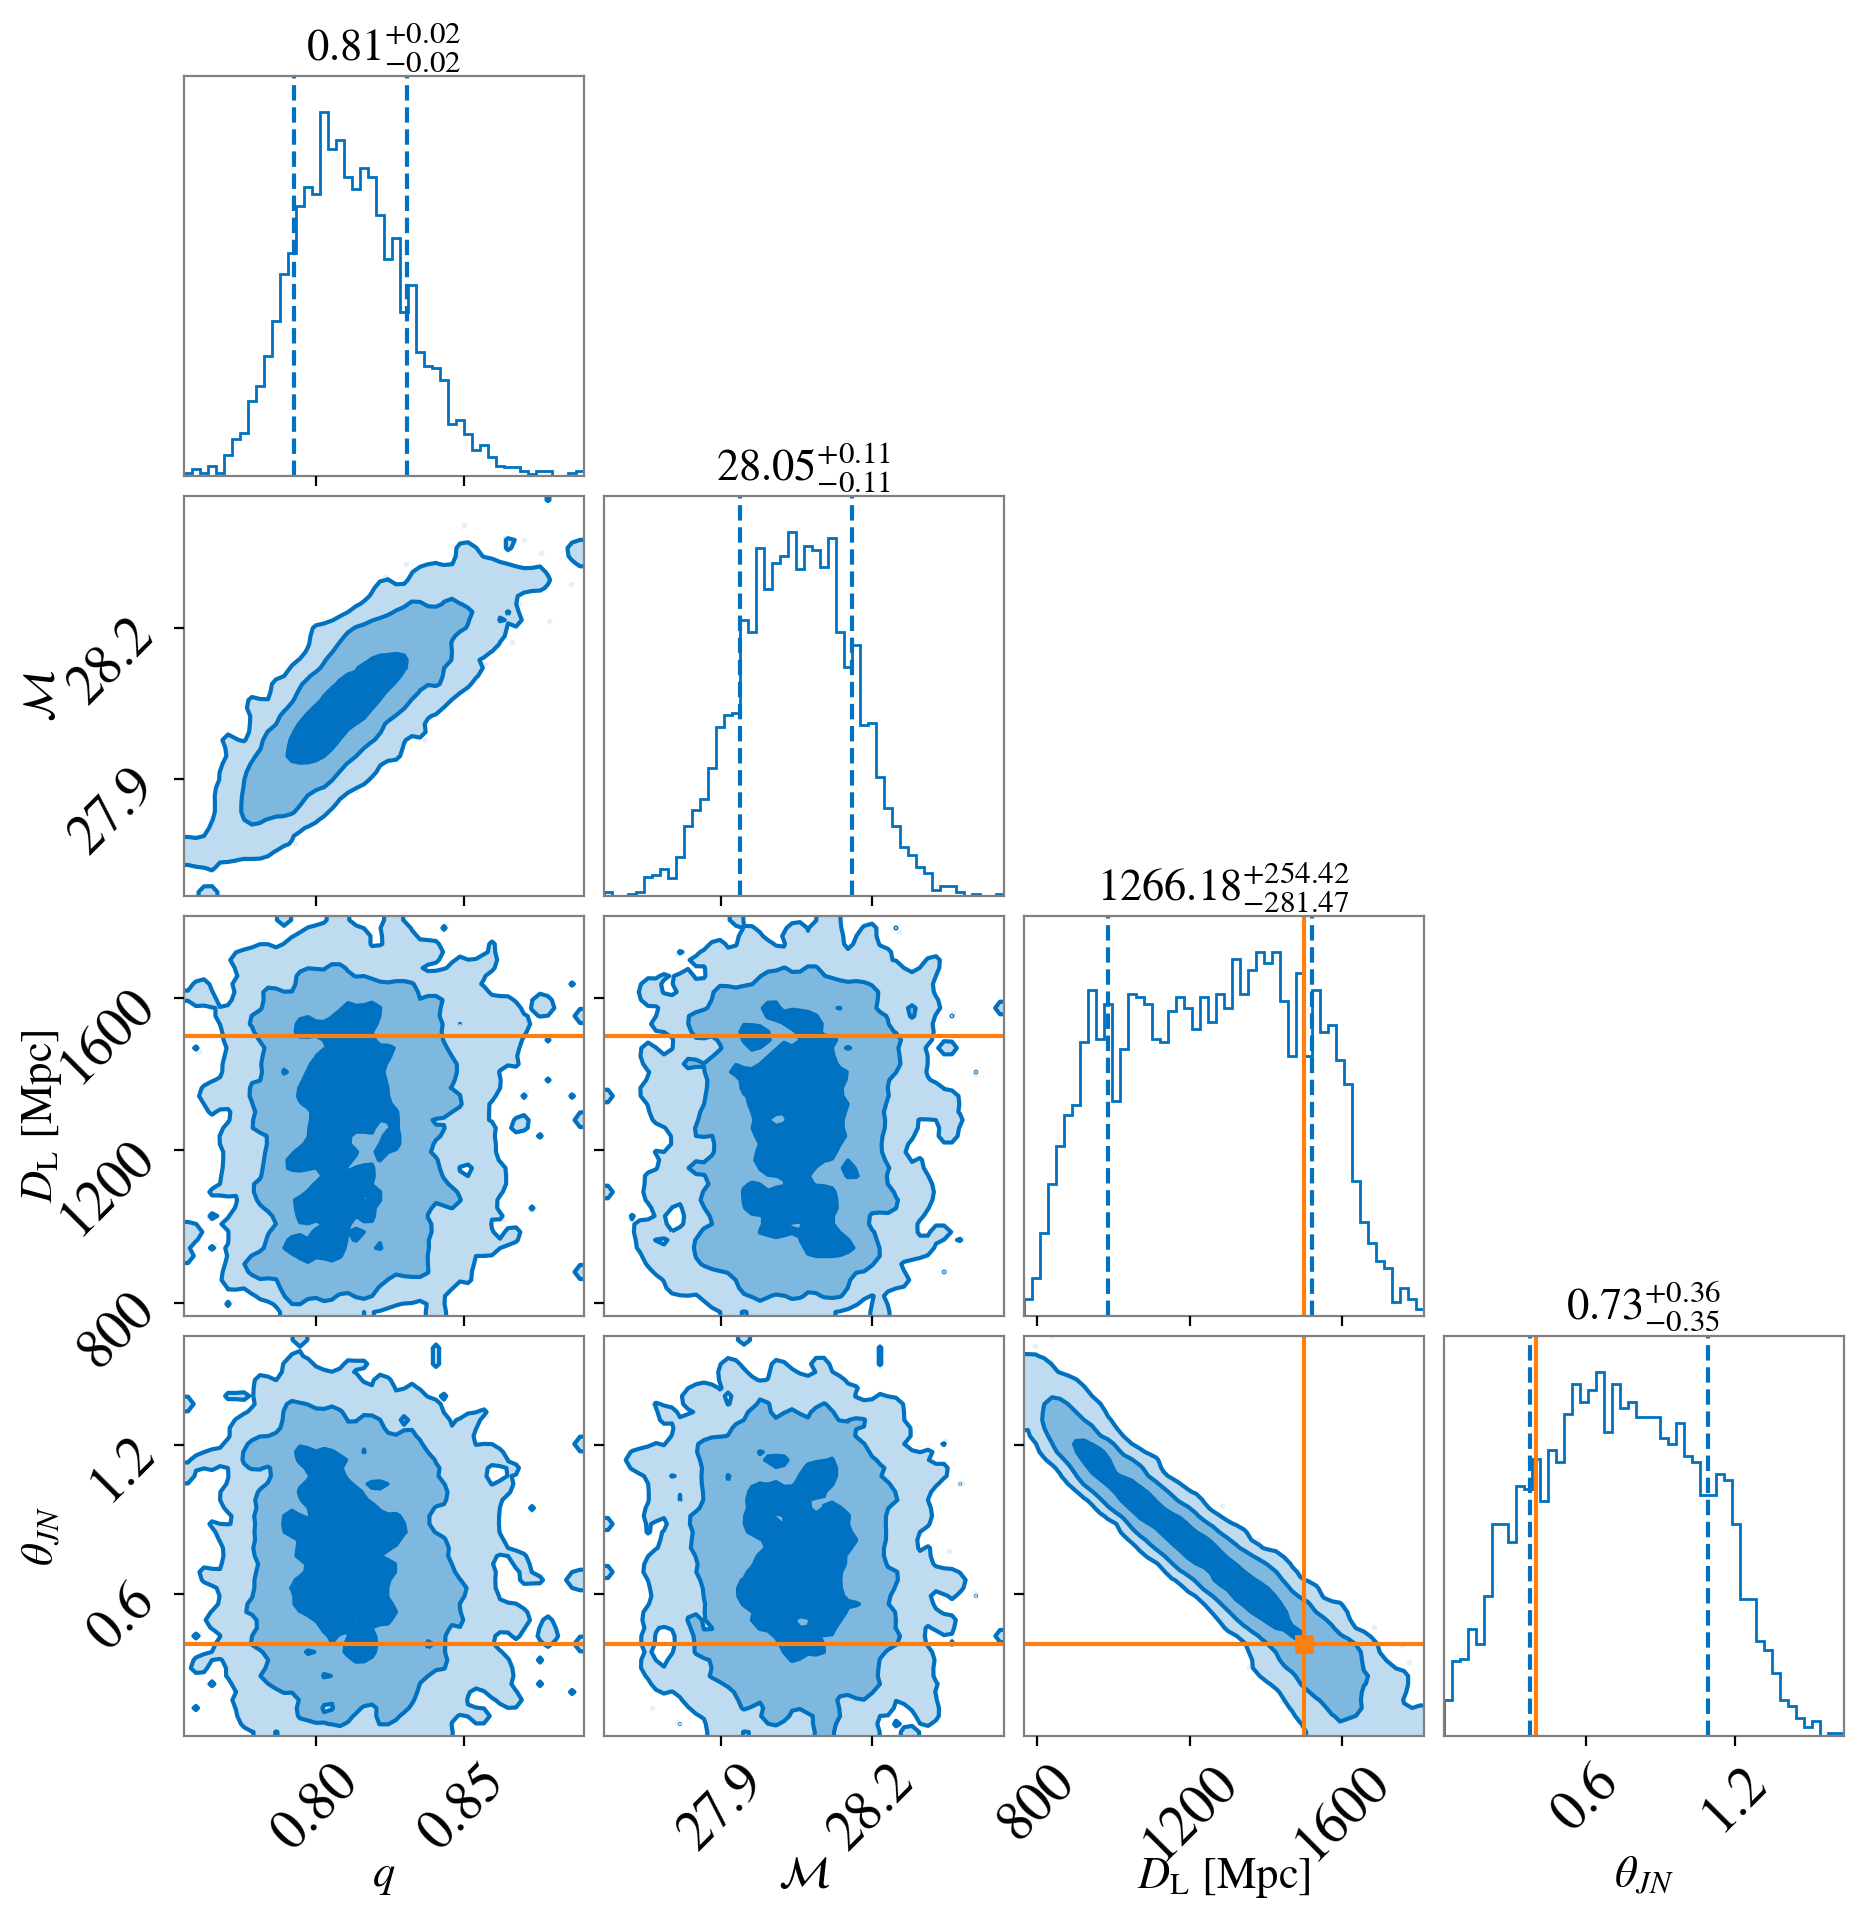

In [16]:
# Make a corner plot.
result.plot_corner()

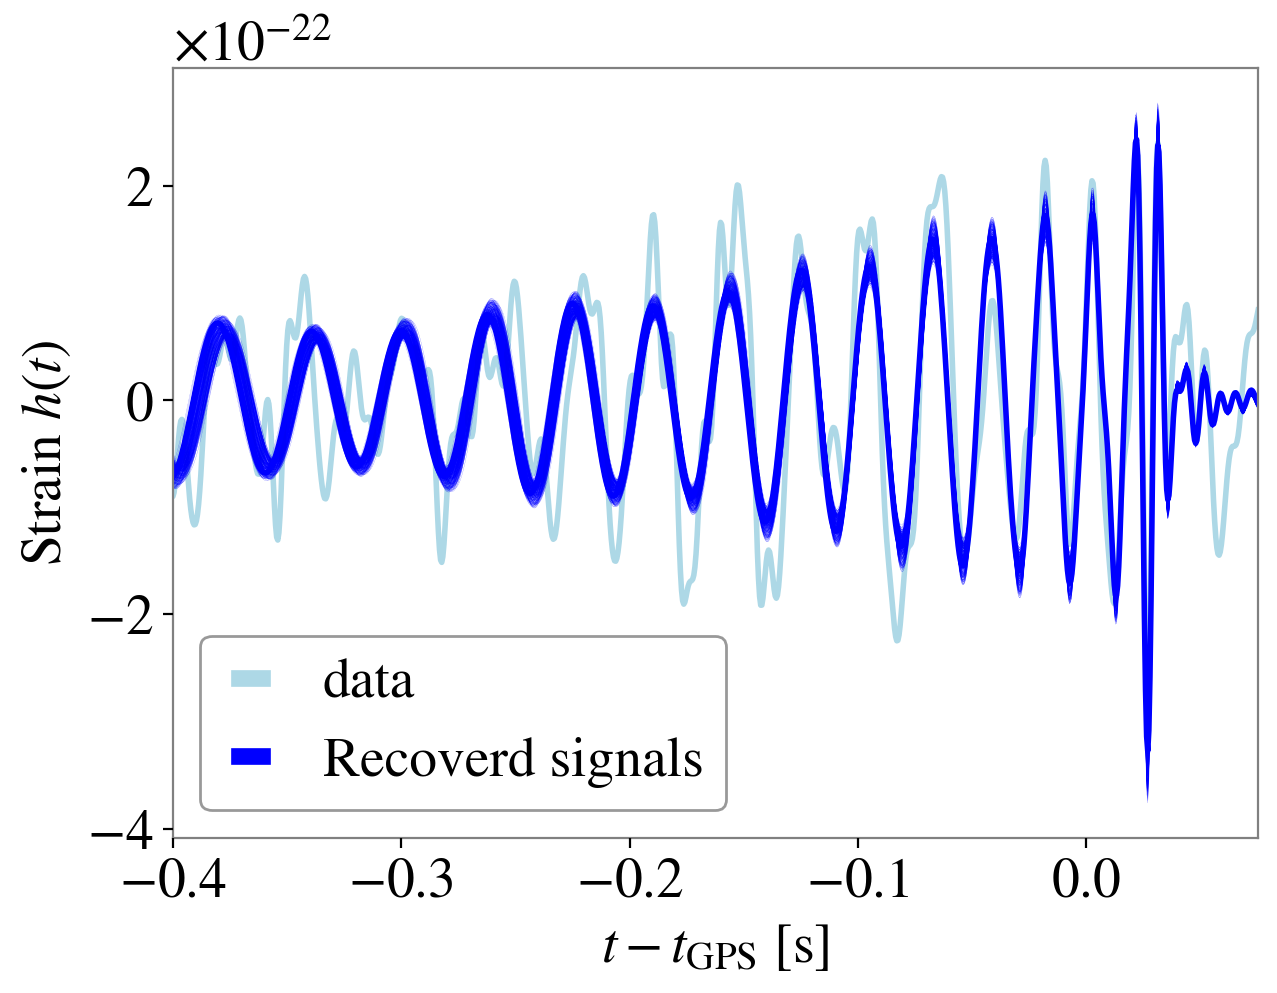

In [19]:
# We quickly plot the data 
fig, ax = plt.subplots(figsize=(7,5))


timeseries = TimeSeries(data=ifos[0].strain_data.time_domain_strain, times=ifos[0].strain_data.time_array)
bandpass_frequencies = [10,150]


zpks = [bandpass(bandpass_frequencies[0], bandpass_frequencies[1],ifos[0].strain_data.sampling_frequency)]
zpk = concatenate_zpks(*zpks)
t0 = injection_parameters['geocent_time']
x = ifos[0].strain_data.time_array - t0

ax.plot(x, timeseries.filter(zpk, filtfilt=True), label="data", lw = 2, color='lightblue')

for i in tqdm(range(300), disable = True):

    one_set_of_parameters = result.posterior.iloc[i].to_dict()
    #print(one_set_of_parameters)    
    
    # Pure signal strain (no noise)
    signal_fd = ifos[0].get_detector_response(
        waveform_generator.frequency_domain_strain(one_set_of_parameters), one_set_of_parameters
    )
    signal_td = np.fft.irfft(signal_fd) * sampling_frequency
    signal_clean = TimeSeries(data=signal_td, times=ifos[0].strain_data.time_array)


    ax.plot(x, signal_clean.filter(zpk, filtfilt=True), #label="Injected signal", 
            lw = 0.1, color = 'b', alpha = 0.5)
    
ax.plot(x, signal_clean.filter(zpk, filtfilt=True), label="Recoverd signals", 
            lw = 2, color = 'b', alpha = 1)


ax.set_xlim([-0.4,0.075])

ax.set_xlabel("$t - t_{\mathrm{GPS}}$ [s]")
ax.set_ylabel("Strain $h(t)$")
ax.legend(fancybox=True)
fig.savefig("{}/{}_time_domain_data_with_waveforms.png".format(outdir, label), dpi = 300) 
    